# Day 4 — Multi-Agent Systems

**Project of the day: an Engineering Design Review Team.** By the last section you will have three
review systems — one reviewer, one reviewer plus deterministic checks, and three specialists
behind a supervisor — measured against a hidden defect list, plus a memo saying which to deploy.

**How to use this notebook**

- Run the cells in order. Every cell prints something; read the output before moving on.
- Nothing to install, no repository to clone: the notebook writes the artifact under review itself.
- Without a key everything runs on a built-in *mock model*: scripted replies, the same validated
  records, the same request shape.
- Each section ends with a two-question checkpoint and a three-line recap.

**Contents**

1. [A review task we can measure](#day-4-section-1)
2. [Single-reviewer baseline](#day-4-section-2)
3. [Deterministic checks before model judgement](#day-4-section-3)
4. [Parallel specialist reviewers](#day-4-section-4)
5. [Supervisor synthesis — you build the merge](#day-4-section-5)
6. [Comparative evaluation](#day-4-section-6)
7. [Project: Engineering Design Review Team](#day-4-section-7)

## Your API key (30 seconds)

The course model runs on OpenRouter. Give this notebook your issued key in one of two ways:

- **Recommended:** click the key icon in Colab's left sidebar, add a secret named
  `OPENROUTER_API_KEY`, and switch on *Notebook access*. Every course notebook then finds it automatically.
- **Or:** run the cell below and paste the key when asked (it is kept only in this session).

No key? Just press Enter when asked. The notebook switches to the mock model and everything still runs.
Never paste a key into a code cell: notebooks get shared.

In [ ]:
# === Setup: run this cell first ===============================================
# It reads your API key, creates the client, and defines chat(): the ONE function
# every reviewer in this notebook uses to talk to the model.
import json, os, re
from getpass import getpass

MODEL = "openai/gpt-oss-120b"          # the course model on OpenRouter

def load_api_key():
    """Look for the key in Colab Secrets, then the environment, then ask once."""
    try:
        from google.colab import userdata           # only exists on Colab
        key = userdata.get("OPENROUTER_API_KEY")
        if key:
            return key, "Colab secret"
    except Exception:
        pass                                        # not on Colab, or no secret yet
    if os.getenv("OPENROUTER_API_KEY"):
        return os.environ["OPENROUTER_API_KEY"], "environment variable"
    try:
        key = getpass("OpenRouter API key (press Enter to use the mock model): ").strip()
    except Exception:                               # no keyboard available (automated run)
        key = ""
    return (key, "typed in") if key else ("", "none")

API_KEY, KEY_SOURCE = load_api_key()
LIVE = bool(API_KEY)                                # True = real model, False = mock model
client = None
if LIVE:
    from openai import OpenAI                       # the OpenAI SDK speaks OpenRouter's API too
    client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=API_KEY)

def chat(messages, tools=None, response_format=None, temperature=0.0, max_tokens=1200):
    """Send ONE request to the model and return a plain dict:
         {"content": str, "tool_calls": [...], "usage": {...}}
    Every reviewer today is a call to this function plus validation of what came back."""
    if not LIVE:
        return mock_model(messages, tools, response_format)
    request = dict(model=MODEL, messages=messages, temperature=temperature, max_tokens=max_tokens,
                   extra_body={"reasoning": {"effort": "low"}})   # keep hidden reasoning short and cheap
    if tools:
        request["tools"] = tools
    if response_format:
        request["response_format"] = response_format
    response = client.chat.completions.create(**request)
    message = response.choices[0].message
    calls = [{"id": call.id, "name": call.function.name,
              "arguments": json.loads(call.function.arguments or "{}")}
             for call in (message.tool_calls or [])]
    usage = response.usage
    return {"content": message.content or "", "tool_calls": calls,
            "usage": {"prompt_tokens": usage.prompt_tokens, "completion_tokens": usage.completion_tokens,
                      "total_tokens": usage.total_tokens}}

print("Model  :", MODEL)
print("Key    :", KEY_SOURCE)
print("Mode   :", "LIVE - real model replies" if LIVE else "MOCK - scripted replies, real shapes, zero cost")

### The mock model (read later, or never)

Without a key, `chat()` hands the request to the function below. Every request today is one kind —
"review this file" — so the mock answers with a **scripted reviewer** returning the JSON a real
model would. Its rules arrive in 4.2, after you have read the artifact yourself.

In [ ]:
MOCK_SCENARIO = "blind_spots"       # which blind spots the scripted reviewer has (section 4.2)

def _mock_reply(content="", prompt_chars=0):
    """Reply in exactly the shape chat() returns, with an honest usage estimate.
    A mock still reports usage: roughly 4 characters per token, not an invented number."""
    prompt_tokens = (prompt_chars + 3) // 4
    completion_tokens = (len(content) + 3) // 4
    return {"content": content, "tool_calls": [],
            "usage": {"prompt_tokens": prompt_tokens, "completion_tokens": completion_tokens,
                      "total_tokens": prompt_tokens + completion_tokens}}

def review_request(messages):
    """Pull (role, artifact text) out of a review request. The request is built in 4.2:
    the system message carries 'Role: <name>' and the user message is a header then the file."""
    system = " ".join(m["content"] for m in messages if m["role"] == "system")
    user = next((m["content"] for m in reversed(messages) if m["role"] == "user"), "")
    match = re.search(r"Role:\s*(\w+)", system)
    return (match.group(1), user.split("\n\n", 1)[-1]) if match else (None, "")

def scripted_findings(source, role, scenario):
    """Stand-in reviewer. Section 4.2 replaces this stub with the real scripted rules."""
    return []

def mock_model(messages, tools=None, response_format=None):
    """The offline model: it answers one kind of request, and answers it in schema shape."""
    role, source = review_request(messages)
    prompt_chars = sum(len(m["content"]) for m in messages)
    if role is None:
        return _mock_reply("The mock model in this notebook only answers review requests.", prompt_chars)
    payload = {"findings": scripted_findings(source, role, MOCK_SCENARIO)}
    return _mock_reply(json.dumps(payload), prompt_chars)

print("mock model ready" + ("" if LIVE else " and active"))

### Carried over from Day 1

One helper: `make_strict`, which turns a Pydantic schema into the strict form a provider enforces.
Findings arrive as JSON, so Day 1's validate-on-the-way-in discipline is today's handoff.

In [ ]:
from typing import Literal
from pydantic import BaseModel, Field, ValidationError

def make_strict(node):
    """Recursively convert a Pydantic JSON schema into the strict form providers accept."""
    if isinstance(node, dict):
        if node.get("type") == "object":
            node["additionalProperties"] = False
            node["required"] = list(node.get("properties", {}).keys())
        for key in ("minItems", "maxItems", "minimum", "maximum", "minLength", "maxLength", "default"):
            node.pop(key, None)
        for value in node.values():
            make_strict(value)
    elif isinstance(node, list):
        for item in node:
            make_strict(item)
    return node

print("carried over from Day 1: make_strict(), plus Pydantic BaseModel / Field / ValidationError")

<a id="day-4-section-1"></a>

## 4.1 — A Review Task We Can Measure

Extra agents cost extra calls, latency and failure modes, so "we used a team of agents" is not a
result. We compare one reviewer, one reviewer plus tools, and a supervised team of three against a
hidden defect list.

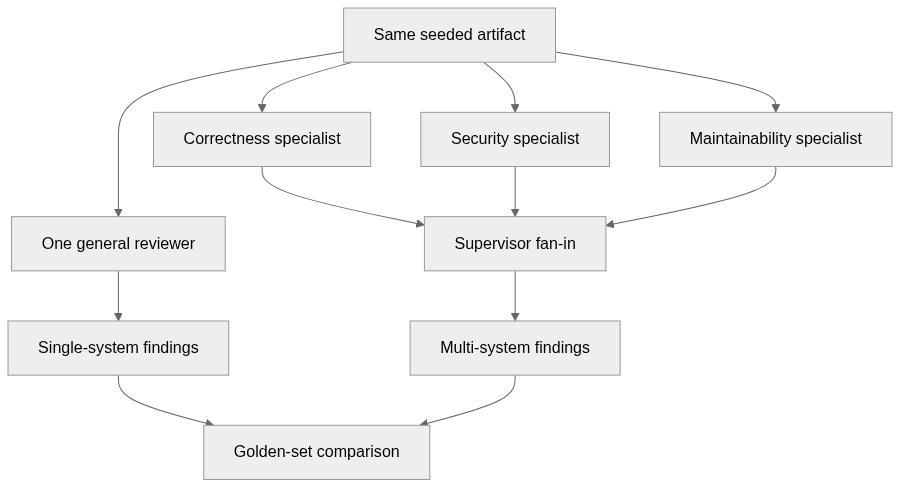

*D12 — one general reviewer and three specialists read the same artifact; both systems are scored against the golden set*

### Step 1 — Create the artifact under review

Everything today reviews this one file: deliberately defective classroom code, never to be
copied. Line numbers matter — a finding without a location cannot be checked or merged.

In [ ]:
from pathlib import Path

DATA_DIR = Path("day_04_data")          # created next to this notebook; no repository needed
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_PATH = DATA_DIR / "order_service.py"

ARTIFACT_PATH.write_text("""# Synthetic classroom artifact: it intentionally contains defects. Never copy it.

ADMIN_TOKEN = "course-demo-admin-token"


def calculate_total(items, discount_code=None, audit=[]):
    subtotal = sum(item["price"] * item["quantity"] for item in items)
    if discount_code == "STUDENT20":
        subtotal = subtotal - 20
    audit.append(subtotal)
    return subtotal


def search_orders(customer_name, database):
    query = "SELECT * FROM orders WHERE customer='" + customer_name + "'"
    return database.execute(query)


def evaluate_shipping(expression):
    return eval(expression)


def average_item_price(items):
    try:
        return sum(item["price"] for item in items) / len(items)
    except Exception:
        return 0


def create_order(user, items):
    print("creating order for", user["email"], "token", user.get("token"))
    total = calculate_total(items)
    return {"owner": user["email"], "items": items, "total": total}
""", encoding="utf-8")

SOURCE = ARTIFACT_PATH.read_text(encoding="utf-8")     # the shared, immutable artifact

for number, line in enumerate(SOURCE.splitlines(), 1):
    print(f"{number:>2}: {line}")

### Step 2 — What a finding has to contain

`Finding` is the contract every reviewer, the supervisor and the evaluator agree on. A reviewer
that cannot fill every field has an opinion, not a finding — and this record is the *only* thing
that crosses a handoff today.

In [ ]:
class Finding(BaseModel):
    """One evidenced review finding, validated the moment it is created."""
    id: str                                                   # identity of this record
    category: Literal["correctness", "security", "maintainability"]
    line: int = Field(ge=1)                                   # 1-based line in the artifact
    title: str = Field(min_length=3)                          # the claim, in one line
    evidence: str = Field(min_length=1)                       # the exact source it rests on
    severity: Literal["low", "medium", "high", "critical"]
    recommendation: str = Field(min_length=3)                 # what to change
    reviewer: str                                             # who said it

lines = SOURCE.splitlines()
example = Finding(id="EXAMPLE-1", category="security", line=3,
                  title="Credential-like token is hardcoded",
                  evidence=lines[2].strip(), severity="high",
                  recommendation="Load secrets from an injected secret store.", reviewer="you")

for name, value in example.model_dump().items():
    print(f"{name:>15}: {value}")

# The contract is enforced, not suggested: a finding with no evidence is not a finding.
try:
    Finding(id="BAD", category="security", line=3, title="Something feels wrong",
            evidence="", severity="high", recommendation="Fix it.", reviewer="you")
except ValidationError as error:
    print("\nrejected  :", error.errors()[0]["loc"][0], "-", error.errors()[0]["msg"])

### Try it yourself

Scroll back to the artifact and pick **two** defects — one `correctness`, one `maintainability`.
Write down the line number and the exact source text for each first.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
# Two defects you can find by reading alone, written as proper Finding records.
my_findings = [
    Finding(id="MINE-1", category="correctness", line=25,        # "... / len(items)"
            title="Empty item list causes division by zero",
            evidence=lines[24].strip(), severity="medium",
            recommendation="Decide what an empty order should return before dividing.",
            reviewer="student"),
    Finding(id="MINE-2", category="maintainability", line=26,    # "except Exception:"
            title="Broad exception handler hides unrelated failures",
            evidence=lines[25].strip(), severity="medium",
            recommendation="Catch only the errors you expect, and log the rest.",
            reviewer="student"),
]

for finding in my_findings:
    print(f"line {finding.line:>3} | {finding.category:<15} | {finding.severity:<6} | {finding.title}")
    print(f"         evidence: {finding.evidence}")
print("\nFindings written BEFORE seeing the answer key:", len(my_findings))

### Step 3 — Now reveal the answer key

The golden set lists every seeded defect, so we can compute **recall** and **false positives**. It
never goes into a reviewer's prompt: a reviewer shown the answers is tested on copying.

In [ ]:
GOLDEN_PATH = DATA_DIR / "golden_defects.json"
GOLDEN_PATH.write_text(json.dumps([
    {"id": "DEF-COR-01", "category": "correctness",     "line": 7,  "title": "Negative quantities are accepted",                "severity": "high"},
    {"id": "DEF-COR-02", "category": "correctness",     "line": 9,  "title": "Flat discount can make the total negative",       "severity": "medium"},
    {"id": "DEF-COR-03", "category": "correctness",     "line": 25, "title": "Empty input causes division by zero",             "severity": "medium"},
    {"id": "DEF-SEC-01", "category": "security",        "line": 3,  "title": "Credential-like token is hardcoded",              "severity": "high"},
    {"id": "DEF-SEC-02", "category": "security",        "line": 15, "title": "SQL query is built by string concatenation",      "severity": "critical"},
    {"id": "DEF-SEC-03", "category": "security",        "line": 20, "title": "Untrusted expression may reach eval",             "severity": "critical"},
    {"id": "DEF-SEC-04", "category": "security",        "line": 31, "title": "Sensitive token is written to logs",              "severity": "high"},
    {"id": "DEF-MNT-01", "category": "maintainability", "line": 6,  "title": "Mutable default argument retains state",          "severity": "medium"},
    {"id": "DEF-MNT-02", "category": "maintainability", "line": 26, "title": "Broad exception hides unrelated failures",        "severity": "medium"},
], indent=1), encoding="utf-8")

GOLDEN = json.loads(GOLDEN_PATH.read_text(encoding="utf-8"))
print("Seeded defects:", len(GOLDEN), "\n")
for category in ("correctness", "security", "maintainability"):
    in_category = [item for item in GOLDEN if item["category"] == category]
    print(f"{category} ({len(in_category)}):")
    for item in in_category:
        print(f"   line {item['line']:>3}  {item['id']}  [{item['severity']}]  {item['title']}")

### Step 4 — Score your own review

Two rules keep scoring honest: a defect is credited **once**, and a finding matching nothing is a
false positive we never quietly drop. Matching is by **location** — real reviewers invent ids.

In [ ]:
def match_to_golden(finding, line_window=1):
    """Return the id of the golden defect this finding describes, or None.
    Same category, and close enough in the file to be the same place."""
    candidates = [item for item in GOLDEN
                  if item["category"] == finding.category
                  and abs(item["line"] - finding.line) <= line_window]
    if not candidates:
        return None
    candidates.sort(key=lambda item: (abs(item["line"] - finding.line), item["id"]))
    return candidates[0]["id"]                       # nearest line wins; id breaks ties

def score(findings, line_window=1):
    """Grade a list of findings against the golden set. Each defect counts once."""
    matched, duplicates, false_positives = [], [], []
    for finding in findings:
        defect_id = match_to_golden(finding, line_window)
        if defect_id is None:
            false_positives.append(finding.id)       # matches no known defect
        elif defect_id in matched:
            duplicates.append(finding.id)            # the same defect, reported again
        else:
            matched.append(defect_id)
    expected = {item["id"] for item in GOLDEN}
    return {"known_defects": len(expected), "found": len(matched),
            "recall": round(len(matched) / len(expected), 3),
            "false_positives": len(false_positives), "duplicates": len(duplicates),
            "reported_findings": len(findings), "missed": sorted(expected - set(matched)),
            "false_positive_ids": false_positives}

my_row = score(my_findings)
for key in ("known_defects", "found", "recall", "false_positives", "duplicates", "missed"):
    print(f"{key:>15}: {my_row[key]}")

### Checkpoint

**1. Why must the golden set stay out of the reviewer's prompt?**

<details><summary>Show answer</summary>

A reviewer shown the answers is tested on copying, not on reviewing. Its recall would measure prompt leakage instead of capability.

</details>

**2. Two reviewers both report the `eval` call on line 20. How many defects were found?**

<details><summary>Show answer</summary>

One. Each defect is credited once; the second is a *duplicate*. Counting both would let a system inflate recall by repeating itself — the failure mode a team of agents risks.

</details>

### Recap

- **Limitation seen:** "the review looked thorough" is not a measurement.
- **Layer added:** a validated `Finding` contract, a hidden golden set, and location-based scoring.
- **Evidence:** two hand-written findings scored automatically, with recall and what was missed.

<a id="day-4-section-2"></a>

## 4.2 — Single-Reviewer Baseline

The simplest system that could work: one reviewer, one call, no tools, no supervisor. Everything
later has to beat it. Live model and scripted stand-in share one request shape and one validator.

### Step 1 — One request shape, one schema

`review_messages` builds the only prompt in this notebook; `Role:` is what narrows a reviewer
later. The reply must be JSON in a fixed shape, so we ask with a strict schema: a prompt raises
the probability, the schema and the validator make it safe.

In [ ]:
class ModelFinding(BaseModel):
    """What the model is allowed to send us: the claim, without ids or provenance."""
    category: Literal["correctness", "security", "maintainability"]
    line: int = Field(ge=1)
    title: str
    evidence: str
    severity: Literal["low", "medium", "high", "critical"]
    recommendation: str

class FindingsReply(BaseModel):
    findings: list[ModelFinding]

FINDINGS_FORMAT = {"type": "json_schema", "json_schema": {
    "name": "FindingsReply", "strict": True,
    "schema": make_strict(FindingsReply.model_json_schema())}}

def review_messages(source, role):
    """The ONE request shape every reviewer sees - live model or scripted stand-in."""
    scope = ("all correctness, security and maintainability concerns" if role == "general"
             else f"only {role} concerns")
    return [
        {"role": "system", "content":
            f"You are a bounded engineering code reviewer. Role: {role}. Report {scope}. "
            "Every finding needs the 1-based line number and the exact source line as evidence. "
            "Report at most 10 findings. Do not invent code."},
        {"role": "user", "content": "Review this Python file:\n\n" + source},
    ]

print(review_messages(SOURCE, "security")[0]["content"])

### Step 2 — Validate before you believe

`parse_findings` turns a reply into `Finding` records or raises. It also enforces the role
contract: a security specialist returning a maintainability finding has broken its bounds, and an
error beats silently widening the role.

In [ ]:
def parse_findings(content, role, max_findings=10):
    """Validate the model's JSON and stamp ids and provenance onto each record."""
    text = content.strip()
    if text.startswith("```"):                                    # models like to fence JSON
        text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text, flags=re.I)
    reply = FindingsReply.model_validate_json(text)               # shape, types, ranges
    if len(reply.findings) > max_findings:
        raise ValueError(f"reviewer returned {len(reply.findings)} findings, cap is {max_findings}")
    findings = []
    for index, item in enumerate(reply.findings, 1):
        if role != "general" and item.category != role:           # the role contract
            raise ValueError(f"{role} reviewer returned a {item.category} finding")
        findings.append(Finding(id=f"MODEL-{role[:3].upper()}-{item.line}-{index}",
                                reviewer=f"{role}_reviewer", **item.model_dump()))
    return findings

# A reply that breaks the contract is rejected loudly, not trusted quietly.
for label, bad in [("wrong category for the role",
                    '{"findings":[{"category":"correctness","line":7,"title":"t","evidence":"e","severity":"low","recommendation":"r"}]}'),
                   ("line number is not a number",
                    '{"findings":[{"category":"security","line":"three","title":"t","evidence":"e","severity":"low","recommendation":"r"}]}')]:
    try:
        parse_findings(bad, "security")
    except (ValidationError, ValueError) as error:
        print(f"{label:<30} -> rejected: {str(error).splitlines()[0][:70]}")

### Step 3 — One reviewer call, whichever model is behind it

`call_reviewer` is the whole reviewer: build the request, send it through a model, validate the
reply. `model` is any function with `chat`'s signature — real, mock, or deliberately broken.

In [ ]:
def call_reviewer(source, role, model=chat):
    """Return (findings, usage). Usage is what the model reported, never an estimate of ours."""
    reply = model(review_messages(source, role), response_format=FINDINGS_FORMAT)
    return parse_findings(reply["content"], role), reply["usage"]

print("call_reviewer ready. It works with any model function:", chat.__name__, "or a stand-in.")

### Step 4 — The scripted reviewer, and why its blind spots are a parameter

In mock mode the reviewer is **scripted, not intelligent**: its blind spots are chosen so the
result is reproducible anywhere. Two worlds — `blind_spots`, where the generalist misses a lot,
and `strong_generalist`, where it nearly matches the team. That is how we compare *architectures*
while holding the reviewer constant.

In [ ]:
import time

# Every seeded defect: id -> (category, source needle, title, severity, recommendation).
# The needle is how a scripted reviewer "locates" a defect in the artifact.
RULES = {
    "DEF-COR-01": ("correctness", "quantity", "Negative quantities are accepted", "high",
                   "Validate that quantity is a positive integer."),
    "DEF-COR-02": ("correctness", "subtotal - 20", "Flat discount can make the total negative", "medium",
                   "Use a percentage and reject invalid totals."),
    "DEF-COR-03": ("correctness", "/ len(items)", "Empty input causes division by zero", "medium",
                   "Define empty-list behaviour before dividing."),
    "DEF-SEC-01": ("security", "ADMIN_TOKEN", "Credential-like token is hardcoded", "high",
                   "Load secrets from an injected secret store."),
    "DEF-SEC-02": ("security", "SELECT * FROM", "SQL query uses string concatenation", "critical",
                   "Use a parameterised query."),
    "DEF-SEC-03": ("security", "eval(", "Untrusted expression may reach eval", "critical",
                   "Replace eval with an allow-listed parser."),
    "DEF-SEC-04": ("security", 'user.get("token")', "Sensitive token is written to logs", "high",
                   "Never log tokens; redact sensitive fields."),
    "DEF-MNT-01": ("maintainability", "audit=[]", "Mutable default argument retains state", "medium",
                   "Default to None and create the list inside."),
    "DEF-MNT-02": ("maintainability", "except Exception", "Broad exception hides failures", "medium",
                   "Catch only the exceptions you expect."),
}
ALL_IDS = sorted(RULES)

SCENARIOS = {
    # World A: one generalist has real blind spots; narrow roles cover them.
    "blind_spots": {
        "general":         ["DEF-COR-03", "DEF-SEC-01", "DEF-SEC-02", "DEF-SEC-03", "DEF-MNT-01"],
        "correctness":     ["DEF-COR-01", "DEF-COR-02", "DEF-COR-03"],
        "security":        ["DEF-SEC-01", "DEF-SEC-02", "DEF-SEC-03", "DEF-SEC-04"],
        "maintainability": ["DEF-MNT-01", "DEF-MNT-02"],
    },
    # World B: the generalist is strong. It misses only the subtle business rule (DEF-COR-02)
    # - and so does the correctness specialist, because narrowing a prompt does not create
    # knowledge the reviewer never had.
    "strong_generalist": {
        "general":         [i for i in ALL_IDS if i != "DEF-COR-02"],
        "correctness":     ["DEF-COR-01", "DEF-COR-03"],
        "security":        ["DEF-SEC-01", "DEF-SEC-02", "DEF-SEC-03", "DEF-SEC-04"],
        "maintainability": ["DEF-MNT-01", "DEF-MNT-02"],
    },
}

def scripted_findings(source, role, scenario=MOCK_SCENARIO):
    """Replaces the stub at the top: the mock model's reviewer, in schema shape."""
    text_lines = source.splitlines()
    out = []
    for defect_id in SCENARIOS[scenario][role]:
        category, needle, title, severity, fix = RULES[defect_id]
        if needle not in source:
            continue
        line = next(i for i, text in enumerate(text_lines, 1) if needle in text)
        out.append({"category": category, "line": line, "title": title,
                    "evidence": text_lines[line - 1].strip(), "severity": severity,
                    "recommendation": fix})            # note: no DEF- id leaks to the reviewer
    return sorted(out, key=lambda item: item["line"])

def make_mock_model(scenario, latency_s=0.0):
    """A stand-in for chat(): same signature, scripted findings, honest usage numbers."""
    def scripted(messages, tools=None, response_format=None):
        role, source = review_request(messages)
        if latency_s:
            time.sleep(latency_s)                      # stands in for a network round trip
        payload = {"findings": scripted_findings(source, role, scenario)}
        return _mock_reply(json.dumps(payload), sum(len(m["content"]) for m in messages))
    return scripted

for name, roles in SCENARIOS.items():
    print(f"{name:<18} general reviewer can see {len(roles['general'])} of 9 defects")

### Step 5 — Run the baseline and read its telemetry

`run_single_reviewer` makes exactly one call and records what it cost. The tokens come from the
model's own usage report: a table of estimates looks identical to a table of measurements.

In [ ]:
from dataclasses import dataclass, field
from time import perf_counter

@dataclass
class ReviewRun:
    """One end-to-end run of one review SYSTEM, with its measured telemetry."""
    system: str
    findings: list = field(default_factory=list)
    model_calls: int = 0
    prompt_tokens: int = 0
    completion_tokens: int = 0
    elapsed_ms: float = 0.0
    raw_findings: int = 0            # findings produced before any merging
    merged_duplicates: int = 0       # how many the supervisor collapsed
    dropped_over_cap: int = 0        # how many the supervisor truncated away
    trace: list = field(default_factory=list)

    @property
    def total_tokens(self):
        return self.prompt_tokens + self.completion_tokens

def run_single_reviewer(source, model):
    """System 1: ask one reviewer about everything, and report exactly what it said."""
    start = perf_counter()
    findings, usage = call_reviewer(source, "general", model)
    return ReviewRun(system="single_reviewer", findings=findings, model_calls=1,
                     prompt_tokens=usage["prompt_tokens"], completion_tokens=usage["completion_tokens"],
                     elapsed_ms=(perf_counter() - start) * 1000, raw_findings=len(findings),
                     trace=[{"step": "general_reviewer", "count": len(findings), "usage": usage}])

reviewer_blind = make_mock_model("blind_spots")          # the scripted reviewer of world A
single = run_single_reviewer(SOURCE, reviewer_blind)

print("System      :", single.system, "| model calls:", single.model_calls)
print("Tokens      :", single.total_tokens, "(prompt", single.prompt_tokens,
      "+ completion", single.completion_tokens, ") as reported by the model")
print("Elapsed ms  : %.2f\n" % single.elapsed_ms)
for finding in single.findings:
    print(f"line {finding.line:>3} | {finding.category:<15} | {finding.severity:<8} | {finding.title}")

### Step 6 — Score it, and see the shape of the hole

`missed` is the list this day exists to shrink — or to prove we cannot shrink it economically.

In [ ]:
baseline_row = score(single.findings)
print("Found          : %d / %d" % (baseline_row["found"], baseline_row["known_defects"]))
print("Recall         :", baseline_row["recall"])
print("False positives:", baseline_row["false_positives"], "| duplicates:", baseline_row["duplicates"])
print("Missed         :", baseline_row["missed"])
print("\nThree of the four misses are security or correctness problems this reviewer never looks at.")

### Step 7 — The live path, and what happens when it fails

The same `call_reviewer`, now through `chat`: real with a key, mock without one. A provider error
must never stop a class, so the reviewer falls back and says so in one line.

In [ ]:
def review_with_fallback(source, role, model=chat, scenario="blind_spots"):
    """Try the given model; on ANY failure print one line and use the scripted reviewer."""
    try:
        return call_reviewer(source, role, model)
    except Exception as error:                    # deliberate classroom safety net
        print(f"  reviewer failed for role={role} ({type(error).__name__}: {error}); "
              "falling back to the scripted reviewer")
        return call_reviewer(source, role, make_mock_model(scenario))

findings, usage = review_with_fallback(SOURCE, "general")
print("Mode           :", "LIVE model" if LIVE else "mock model")
print("Findings       :", len(findings), "| usage reported:", usage)
print("Valid records  :", all(isinstance(f, Finding) for f in findings), "- same contract either way")

# Prove the safety net works, using a model that always fails.
def broken_model(messages, tools=None, response_format=None):
    raise RuntimeError("503 provider unavailable")

recovered, _ = review_with_fallback(SOURCE, "general", model=broken_model)
print("After the failure:", len(recovered), "findings - the lesson continues")

### Try it yourself

Swap in the `strong_generalist` reviewer: same architecture, one call, no specialists. How many
of the 9 defects will it find? Write your number down, then run the worked solution.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
# Same architecture (run_single_reviewer), different reviewer. Only the blind spots move.
reviewer_strong = make_mock_model("strong_generalist")
strong_row = score(run_single_reviewer(SOURCE, reviewer_strong).findings)

print("blind_spots       reviewer found %d/9  (missed %s)" % (baseline_row["found"], baseline_row["missed"]))
print("strong_generalist reviewer found %d/9  (missed %s)" % (strong_row["found"], strong_row["missed"]))
print("\nBoth runs made 1 model call. The architecture did not change; the reviewer did.")
print("Remember this the moment someone proposes adding agents.")

### Checkpoint

**1. Why does every reviewer — mock, live, and the broken one — go through the same `call_reviewer` contract?**

<details><summary>Show answer</summary>

So we can change one variable at a time: a difference in results then comes from the architecture or the reviewer, never from a rewritten pipeline.

</details>

**2. The run reports `prompt_tokens` from the model instead of estimating them from the file's length. Why does that matter?**

<details><summary>Show answer</summary>

An estimate in a results table looks exactly like a measurement. If a step that made no call shows a plausible token count, every cost comparison on that table is fiction.

</details>

### Recap

- **Limitation seen:** one general reviewer found 5 of 9 defects and missed a whole category's worth.
- **Layer added:** one request shape, one validator, one reviewer contract, with a fallback.
- **Evidence:** 5/9 recall from 1 call, and a forced provider failure that did not stop the run.

<a id="day-4-section-3"></a>

## 4.3 — Deterministic Checks Before Model Judgement

Some defects are facts: a parser can *prove* that a file calls `eval`, has a mutable default, or
swallows every exception. Proving costs nothing. Spend model calls on what is left.

### Step 1 — What a parser can prove

`ast` turns the source into a tree; walking it establishes three defects with no judgement. Note
the ids: a real analyser invents its own — which is why the evaluator matches by location.

In [ ]:
import ast

def deterministic_checks(source):
    """Walk the syntax tree and report the patterns a parser can establish as facts."""
    tree = ast.parse(source)                       # parse once; raises SyntaxError on bad input
    text_lines = source.splitlines()
    def excerpt(lineno):
        return text_lines[lineno - 1].strip() if 0 < lineno <= len(text_lines) else ""
    findings = []
    for node in ast.walk(tree):
        # 1) A direct call to eval() is a fact.
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Name) and node.func.id == "eval":
            findings.append(Finding(id=f"AST-EVAL-{node.lineno}", category="security", line=node.lineno,
                                    title="Call to eval()", evidence=excerpt(node.lineno), severity="critical",
                                    recommendation="Use an allow-listed parser instead of eval.", reviewer="ast_checker"))
        # 2) A mutable default argument is visible in the signature.
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
            if any(isinstance(d, (ast.List, ast.Dict, ast.Set)) for d in node.args.defaults):
                findings.append(Finding(id=f"AST-MUTABLE-DEFAULT-{node.lineno}", category="maintainability",
                                        line=node.lineno, title="Mutable default argument", evidence=excerpt(node.lineno),
                                        severity="medium", recommendation="Default to None and build the container inside.",
                                        reviewer="ast_checker"))
        # 3) `except Exception:` swallows unrelated failures.
        if isinstance(node, ast.ExceptHandler) and isinstance(node.type, ast.Name) and node.type.id == "Exception":
            findings.append(Finding(id=f"AST-BROAD-EXCEPT-{node.lineno}", category="maintainability",
                                    line=node.lineno, title="Broad exception handler", evidence=excerpt(node.lineno),
                                    severity="medium", recommendation="Catch only the exceptions you expect.",
                                    reviewer="ast_checker"))
    return sorted(findings, key=lambda f: (f.line, f.id))

checks = deterministic_checks(SOURCE)
print("Deterministic findings:", len(checks), "\n")
for finding in checks:
    print(f"line {finding.line:>3} | {finding.category:<15} | {finding.id:<26} | {finding.title}")
    print(f"         evidence: {finding.evidence}   -> golden defect {match_to_golden(finding)}")

### Step 2 — Measure what the proof cost

The whole argument for running tools first: the same evidence, for nothing, every time.

In [ ]:
start = perf_counter()
for _ in range(100):
    deterministic_checks(SOURCE)                   # 100 passes so the timer has something to see
print("Average time per AST pass  : %.3f ms" % ((perf_counter() - start) * 1000 / 100))
print("Model calls / tokens / cost: 0 / 0 / $0.000000")
print("Same answer on every run   : yes (same tree, same rules)")

### Step 3 — Checks plus one reviewer, with nothing merging them yet

Put the parser's three findings in front of the reviewer's five and score the pile. Recall rises
for zero extra tokens — and two defects are reported twice, because nothing merges them yet.

In [ ]:
reviewer_findings, reviewer_usage = call_reviewer(SOURCE, "general", reviewer_blind)
combined = checks + reviewer_findings              # plain concatenation: no merge rule at all
combined_row = score(combined)

print(f"{'system':<26}{'findings':>9}{'found':>7}{'dupes':>7}{'calls':>7}{'tokens':>8}")
print("-" * 64)
print(f"{'single_reviewer':<26}{len(reviewer_findings):>9}{baseline_row['found']:>7}"
      f"{baseline_row['duplicates']:>7}{1:>7}{single.total_tokens:>8}")
print(f"{'checks + reviewer (raw)':<26}{len(combined):>9}{combined_row['found']:>7}"
      f"{combined_row['duplicates']:>7}{1:>7}{single.total_tokens:>8}")
print("\nDefect gained by adding the parser:",
      sorted(set(baseline_row["missed"]) - set(combined_row["missed"])))
print("Extra model calls and tokens to gain it: 0 and 0")
print("Duplicates now in the report          :", combined_row["duplicates"], "- unmerged, and a reader has to triage them")

### Step 4 — Where the parser stops

None of the defects still missing are syntax facts. Each needs judgement about intent — where a
model earns its cost.

In [ ]:
print("Still missed after the parser ran:")
for defect_id in combined_row["missed"]:
    item = next(x for x in GOLDEN if x["id"] == defect_id)
    print(f"   {defect_id}  line {item['line']:>3}  {item['title']}")
print("\nBusiness rules, not syntax: a parser cannot know that a flat 20-unit discount is wrong.")

### Try it yourself

Of the parser's three findings, how many had the reviewer *already* reported? Predict, then run
the worked solution.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
# Two findings are the same defect if they match the same golden id.
reviewer_defects = {match_to_golden(f) for f in reviewer_findings}
for finding in checks:
    defect = match_to_golden(finding)
    status = "already reported by the reviewer" if defect in reviewer_defects else "NEW"
    print(f"{finding.id:<26} -> {defect}  {status}")
print("\nOverlap is not waste here: it costs 0 tokens and upgrades a model's claim into a parser's proof.")
print("It becomes waste when you pay a second MODEL CALL to rediscover a fact ordinary code proved.")

### Checkpoint

**1. The parser and the reviewer both reported the `eval` call on line 20. Is that wasted work?**

<details><summary>Show answer</summary>

No: it is free (0 tokens) and upgrades a claim into a proof. It becomes waste when a *second model call* rediscovers what ordinary code already established.

</details>

**2. The deterministic step will write `model_calls: 0` into the trace instead of leaving the field out. Why?**

<details><summary>Show answer</summary>

An absent number gets filled in by whoever reads the table next. An explicit zero labelled "no model call" keeps the free step visible in every cost comparison.

</details>

### Recap

- **Limitation seen:** the reviewer missed defects a parser proves in under a millisecond.
- **Layer added:** an AST checker whose findings carry their own ids and are matched by location.
- **Evidence:** recall 5/9 → 6/9 for 0 extra calls — and 2 unmerged duplicates that now need a supervisor.

<a id="day-4-section-4"></a>

## 4.4 — Parallel Specialist Reviewers

Three narrow reviewers read the same file and answer different questions about it. Say the words
precisely — fan-out, shared state, handoff, fan-in — because each is a place these systems break.

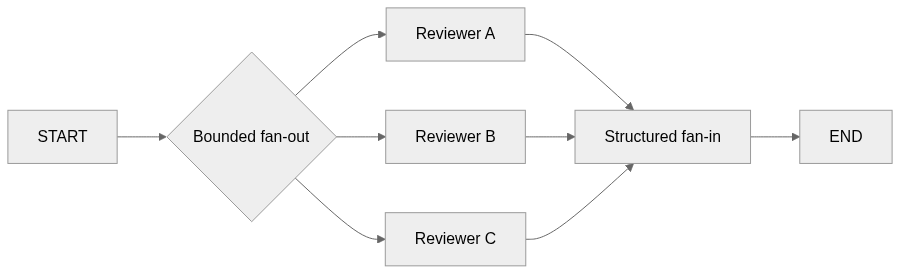

*D13 — one bounded fan-out into three reviewers, then a structured fan-in*

### Step 1 — The vocabulary, on this exact example

- **Shared state** — what every branch reads: `SOURCE`, one immutable string. Nothing writes to
  it, which is why the branches are safe to run at the same time.
- **Fan-out** — one step launches independent branches. Ours is bounded: three roles, three calls,
  and no branch may spawn another.
- **Handoff** — what crosses the boundary between agents. Only `Finding` records: no personas, no
  chat history, no hidden reasoning.
- **Fan-in** — one step collects every branch's output and combines it: the supervisor, in 4.5.

Narrowing a prompt redistributes attention; it does not create capability. If the generalist
cannot see a business rule, a narrower specialist usually cannot either.

In [ ]:
SPECIALIST_ROLES = ("correctness", "security", "maintainability")

print("Bounded fan-out width:", len(SPECIALIST_ROLES), "| roles:", list(SPECIALIST_ROLES))
print("Shared state         : one immutable string of", len(SOURCE), "characters")
print("Does any branch write to it? no - each returns its own list of findings\n")

for role in SPECIALIST_ROLES:
    role_findings, _usage = call_reviewer(SOURCE, role, reviewer_blind)
    print(f"{role:<16} -> {len(role_findings)} finding(s): "
          + ", ".join(f"line {f.line}" for f in role_findings))
    assert all(f.category == role for f in role_findings)     # enforced by parse_findings
print("\nEvery finding stayed inside its reviewer's category - the role contract held.")

### Step 2 — Look at one handoff record

The entire message the security specialist sends onward. Compare it with "here is my
conversation, please read it": small, validated, mergeable.

In [ ]:
handoff, _usage = call_reviewer(SOURCE, "security", reviewer_blind)
for name, value in handoff[0].model_dump().items():
    print(f"{name:>15}: {value}")
print("\nWhat is NOT in the handoff: the prompt, the reasoning, the chat history.")

### Step 3 — Sequential first, because it is easy to debug

`fan_out` runs the three branches: call one, wait, call the next. The mock gets a 0.3 s delay so
it behaves like a network call.

In [ ]:
from concurrent.futures import ThreadPoolExecutor

def fan_out(source, model, parallel=True):
    """Run every specialist over the same immutable source. Returns [(role, findings, usage)]."""
    def branch(role):
        role_findings, usage = call_reviewer(source, role, model)    # each branch: 1 model call
        return role, role_findings, usage
    if parallel:
        # Bounded at exactly three workers: three roles, three calls, no branch spawns another.
        with ThreadPoolExecutor(max_workers=len(SPECIALIST_ROLES)) as pool:
            return list(pool.map(branch, SPECIALIST_ROLES))
    return [branch(role) for role in SPECIALIST_ROLES]

slow_reviewer = make_mock_model("blind_spots", latency_s=0.3)        # pretend network latency

start = perf_counter()
sequential = fan_out(SOURCE, slow_reviewer, parallel=False)
sequential_seconds = perf_counter() - start

print("Execution  : sequential")
print("Branches   :", [role for role, _f, _u in sequential])
print("Model calls:", len(sequential), "| tokens:", sum(u["total_tokens"] for _r, _f, u in sequential))
print("Wall clock : %.2f s" % sequential_seconds)

### Step 4 — Now fan out into threads

`ThreadPoolExecutor` starts the three calls together: while one branch waits on the network the
others wait too, so the total is roughly the *longest* call, not the sum.

In [ ]:
start = perf_counter()
parallel = fan_out(SOURCE, slow_reviewer, parallel=True)
parallel_seconds = perf_counter() - start

print(f"{'measure':<22}{'sequential':>12}{'parallel':>12}")
print("-" * 46)
print(f"{'wall clock (s)':<22}{sequential_seconds:>12.2f}{parallel_seconds:>12.2f}")
print(f"{'model calls':<22}{len(sequential):>12}{len(parallel):>12}")
print(f"{'tokens':<22}{sum(u['total_tokens'] for _r, _f, u in sequential):>12}"
      f"{sum(u['total_tokens'] for _r, _f, u in parallel):>12}")
print(f"{'findings':<22}{sum(len(f) for _r, f, _u in sequential):>12}"
      f"{sum(len(f) for _r, f, _u in parallel):>12}")
print("\nSpeed-up: %.1fx" % (sequential_seconds / parallel_seconds))
print("Parallel execution buys wall-clock time. It does not reduce calls, tokens or cost,")
print("and it reaches a provider's rate limit three times faster.")

### Try it yourself

The pool is capped at three workers. Predict the wall clock at **one** worker instead.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
# Fan out by hand so the bound is visible: max_workers is the whole cap.
def timed_fan_out(max_workers):
    start = perf_counter()
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        results = list(pool.map(lambda role: call_reviewer(SOURCE, role, slow_reviewer), SPECIALIST_ROLES))
    return perf_counter() - start, sum(len(f) for f, _u in results)

for workers in (1, 2, 3):
    seconds, total = timed_fan_out(workers)
    print("max_workers=%d -> %.2f s, %d findings, 3 model calls" % (workers, seconds, total))
print("\nmax_workers=1 is sequential execution wearing a thread pool.")
print("The findings and the bill never change; only how long we wait does.")

### Checkpoint

**1. Why is it safe to run these three reviewers at the same time?**

<details><summary>Show answer</summary>

The shared state is read-only: each branch reads the same immutable `SOURCE` and writes only to its own list, so no order of execution can make them interfere. A branch that *modified* shared state would need locking or a merge rule.

</details>

**2. Your manager says "run the specialists in parallel to cut our API bill". What do you reply?**

<details><summary>Show answer</summary>

Parallelism does not touch the bill: both runs made the same 3 calls with the same tokens; only the wall clock fell. To cut cost you must remove calls.

</details>

### Recap

- **Limitation seen:** running three specialists one after another costs the sum of all three waits.
- **Layer added:** a bounded fan-out over read-only state, with `Finding` records as the only handoff.
- **Evidence:** roughly 0.9 s → 0.3 s wall clock with identical findings, calls and tokens.

<a id="day-4-section-5"></a>

## 4.5 — Supervisor Synthesis — You Build the Merge

Four branches now produce findings for nine defects, several describing the same problem under
different ids. The fan-in step must merge, rank, cap, stop — and say what it did. Today's one
hands-on exercise: write `merge_findings`, check it, then use it for the rest of the day.

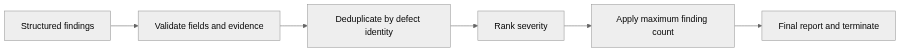

*D14 — validate, deduplicate by defect identity, rank by severity, cap the report, terminate*

### Step 1 — What arrives at the fan-in point

The AST checker plus three specialists. Nothing has been merged, so the same defect appears more
than once under ids nobody shares.

In [ ]:
branch_results = [{"status": "ok", "findings": deterministic_checks(SOURCE)}]
branch_results += [{"status": "ok", "findings": findings}
                   for _role, findings, _usage in fan_out(SOURCE, reviewer_blind)]
labels = ["ast_checker", *SPECIALIST_ROLES]

for label, branch in zip(labels, branch_results):
    print(f"{label:<16} produced {len(branch['findings'])} finding(s)")
incoming = [f for branch in branch_results for f in branch["findings"]]
print("\nTotal arriving at the supervisor:", len(incoming), "for", len(GOLDEN), "real defects\n")

for finding in sorted(incoming, key=lambda f: f.line):
    print(f"line {finding.line:>3} | {finding.category:<15} | {finding.id:<26} | {finding.reviewer}")

### Step 2 — Deduplication is harder than matching ids

A static checker calls the line-20 problem `AST-EVAL-20`; a model calls it `MODEL-SEC-20-3`. Same
defect, two ids, two survivors in the report. So the supervisor needs a rule that does not depend
on shared ids — same category, lines close enough to be the same place — and that rule can be
wrong in both directions. Merging must never be silent.

In [ ]:
SEVERITY_RANK = {"low": 1, "medium": 2, "high": 3, "critical": 4}

@dataclass
class SynthesisReport:
    """What the supervisor did, so merging and truncation are never silent."""
    findings: list                 # the findings that survived, ranked
    received: int = 0              # how many arrived from all branches
    merged_duplicates: int = 0     # how many were collapsed into another finding
    kept: int = 0                  # how many were returned
    dropped_over_cap: int = 0      # how many were cut by max_findings
    failed_branches: int = 0       # branches that reported an error instead of findings
    merge_key: str = "location"    # which rule was used

def stronger(candidate, current):
    """Prefer the higher severity; break ties on id so the result is stable across runs."""
    if SEVERITY_RANK[candidate.severity] != SEVERITY_RANK[current.severity]:
        return SEVERITY_RANK[candidate.severity] > SEVERITY_RANK[current.severity]
    return candidate.id < current.id

print("Severity ranking:", SEVERITY_RANK)
print("A SynthesisReport carries the findings AND the accounting:",
      [f.name for f in SynthesisReport.__dataclass_fields__.values()])

### Your turn — write the supervisor

```python
merge_findings(branches, merge_by="location", line_window=1, max_findings=20) -> SynthesisReport
```

`branches` is a list of `{"status": "ok", "findings": [...]}`; a failed branch carries
`{"status": "error", "error": "..."}`. Rules: skip failed branches (one dead specialist must not
erase the others); two findings are the same defect if their **ids** match (`merge_by="id"`) or
they share a **category and are within `line_window` lines** (`merge_by="location"`); when two
merge keep the `stronger` one; rank by severity, then line, then id; cap at `max_findings` and
record how many were dropped.

In [ ]:
def merge_findings(branches, merge_by="location", line_window=1, max_findings=20):
    """YOUR TURN. Return a SynthesisReport: merged, ranked, capped, and fully accounted for."""
    # TODO: collect findings from branches whose status is "ok"; count and announce the failures
    # TODO: for each finding, look for an already-kept finding that is the SAME defect
    # TODO:     merge_by="id"       -> same id
    # TODO:     merge_by="location" -> same category and abs(line difference) <= line_window
    # TODO: on a match: merged_duplicates += 1 and keep the stronger() of the two
    # TODO: otherwise: keep it
    # TODO: rank by (-SEVERITY_RANK[severity], line, id), cap at max_findings, record the rest
    raise NotImplementedError("write the supervisor merge")

print("merge_findings stub defined - fill in the TODOs, then run the check below")

### Behavioural check

Four cases, all deterministic and free. It prints a hint instead of failing while your function is
unfinished.

In [ ]:
def make_finding(id, category, line, severity):
    """A tiny Finding for the checks; the other fields do not affect merging."""
    return Finding(id=id, category=category, line=line, title="check finding", evidence="x",
                   severity=severity, recommendation="fix it", reviewer="check")

def run_merge_checks():
    ok_one = {"status": "ok", "findings": [make_finding("A-1", "security", 15, "critical")]}
    ok_two = {"status": "ok", "findings": [make_finding("B-1", "correctness", 7, "high")]}
    failed = {"status": "error", "error": "timeout"}

    # 1) A failed branch must not erase the others.
    report = merge_findings([ok_one, failed, ok_two])
    assert [f.id for f in report.findings] == ["A-1", "B-1"], report.findings
    assert report.failed_branches == 1 and report.received == 2, report

    # 2) Severity beats id order: Z-1 (critical) must survive and outrank A-9 (low).
    same_place = {"status": "ok", "findings": [make_finding("A-9", "security", 20, "low"),
                                               make_finding("Z-1", "security", 20, "critical")]}
    report = merge_findings([same_place])
    assert [f.id for f in report.findings] == ["Z-1"], "keep the stronger record when two merge"
    assert report.merged_duplicates == 1, report

    # 3) merge_by="id" keeps both, because the ids differ.
    report = merge_findings([same_place], merge_by="id")
    assert [f.id for f in report.findings] == ["Z-1", "A-9"], "id merging leaves cross-reviewer duplicates"

    # 4) The cap must be reported, never silent.
    report = merge_findings([ok_one, ok_two], max_findings=1)
    assert report.kept == 1 and report.dropped_over_cap == 1, report
    print("PASS: failed branches tolerated, duplicates merged by severity, id rule differs, cap reported")

try:
    run_merge_checks()
except NotImplementedError:
    print("Not implemented yet. Fill in merge_findings above, or read the reference solution below and re-run this cell.")

### Reference solution

Read it line by line even if your check passed. **This version is the supervisor used for the
rest of the day.**

In [ ]:
# --- Reference solution ------------------------------------------------------------
def merge_findings(branches, merge_by="location", line_window=1, max_findings=20):
    if merge_by not in {"id", "location"}:
        raise ValueError("merge_by must be 'id' or 'location'")

    incoming, failed = [], 0
    for branch in branches:
        if branch.get("status") != "ok":                  # one dead specialist must not erase the rest
            failed += 1
            print("  supervisor: ignoring failed branch -", branch.get("error"))
            continue
        incoming.extend(branch["findings"])

    kept, merged = [], 0
    for finding in incoming:
        match = None
        for index, existing in enumerate(kept):
            same = (finding.id == existing.id) if merge_by == "id" else (
                finding.category == existing.category
                and abs(finding.line - existing.line) <= line_window)
            if same:
                match = index
                break
        if match is None:
            kept.append(finding)                          # first time we have seen this defect
        else:
            merged += 1                                   # a duplicate: keep the stronger record
            if stronger(finding, kept[match]):
                kept[match] = finding

    ranked = sorted(kept, key=lambda f: (-SEVERITY_RANK[f.severity], f.line, f.id))
    final = ranked[:max_findings]                         # bounded output: the supervisor terminates
    return SynthesisReport(findings=final, received=len(incoming), merged_duplicates=merged,
                           kept=len(final), dropped_over_cap=len(ranked) - len(final),
                           failed_branches=failed, merge_key=merge_by)

run_merge_checks()

### Step 3 — Run both rules on the real branches

Same twelve findings, two rules. The id rule leaves both versions of a defect side by side; the
location rule collapses them.

In [ ]:
by_id = merge_findings(branch_results, merge_by="id")
by_location = merge_findings(branch_results, merge_by="location")

print(f"{'rule':<12}{'received':>10}{'merged':>9}{'kept':>7}{'defects found':>15}{'duplicates':>12}")
print("-" * 65)
for report in (by_id, by_location):
    row = score(report.findings)
    print(f"{report.merge_key:<12}{report.received:>10}{report.merged_duplicates:>9}{report.kept:>7}"
          f"{row['found']:>15}{row['duplicates']:>12}")

print("\nFinal report (location rule), ranked by severity then line:")
for finding in by_location.findings:
    print(f"   {finding.severity:<8} line {finding.line:>3}  {finding.title}  [{finding.reviewer}]")

### Step 4 — The same rule can delete a real defect

Location merging cannot know whether two nearby findings are one defect or two. Here are two
genuinely different security problems, one line apart.

In [ ]:
first = Finding(id="A", category="security", line=15, title="SQL built by string concatenation",
                evidence="query = ... + customer_name", severity="critical",
                recommendation="Parameterise it.", reviewer="sec_a")
second = Finding(id="B", category="security", line=16, title="Result returned without an authorisation check",
                 evidence="return database.execute(query)", severity="high",
                 recommendation="Check the caller.", reviewer="sec_b")

merged = merge_findings([{"status": "ok", "findings": [first, second]}])
print("Two different defects went in :", [f.title for f in (first, second)])
print("Came out of the supervisor    :", merged.kept, "finding(s):", [f.title for f in merged.findings])
print("\nFALSE MERGE: a real defect was deleted by the deduplication rule.")
print("Loosen the rule and you hide defects; tighten it and duplicates survive.")
print("No window is right for every artifact - which is why production systems keep a human here.")

### Step 5 — Capping must not be silent

A supervisor has to terminate, so it caps the report. Truncating silently makes "we found nothing
else" and "we stopped looking" identical.

In [ ]:
capped = merge_findings(branch_results, merge_by="location", max_findings=4)
print("Kept             :", capped.kept, "| dropped over cap:", capped.dropped_over_cap)
for finding in capped.findings:
    print(f"   {finding.severity:<8} line {finding.line:>3}  {finding.title}")
dropped = {f.id for f in by_location.findings} - {f.id for f in capped.findings}
print("\nDropped, and reported as dropped:", len(dropped), "findings on lines",
      sorted(f.line for f in by_location.findings if f.id in dropped))

### Checkpoint

**1. Why can't the supervisor simply deduplicate on the finding id?**

<details><summary>Show answer</summary>

Ids are only shared inside this classroom: the parser says `AST-EVAL-20`, the model says `MODEL-SEC-20-3`. Id merging left 3 duplicates that location merging removed.

</details>

**2. The supervisor caps the report at N findings. What does it owe the reader when it hits that cap?**

<details><summary>Show answer</summary>

The number it dropped. A cap is a legitimate way to terminate; silent truncation hides real findings. `SynthesisReport` records `dropped_over_cap`.

</details>

### Recap

- **Limitation seen:** four branches produced 12 findings for 9 defects, and id merging left duplicates.
- **Layer added:** a bounded fan-in that tolerates a failed branch, merges by category plus line proximity, ranks, caps, and reports what it cut.
- **Evidence:** 12 → 9 findings with 0 duplicates, plus a false merge deleting a real defect.

<a id="day-4-section-6"></a>

## 4.6 — Comparative Evaluation

Three systems, one artifact, one hidden answer key — scored twice, against two reviewers. The
winner is not the same both times, and the single reviewer is allowed to win.

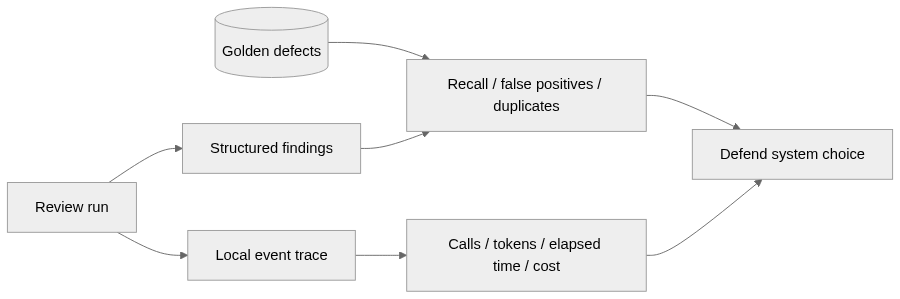

*D15 — findings and event trace from a run, scored against the golden defects, produce the decision*

### Step 1 — Assemble the two remaining systems

Nothing new: the checker from 4.3, the fan-out from 4.4, the supervisor from 4.5. Note the trace
entry for the deterministic step — an explicit zero, so no free step borrows a model's numbers.

In [ ]:
NO_MODEL_CALL = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0,
                 "note": "no model call - deterministic code"}

def run_checks_plus_reviewer(source, model, max_findings=20, merge_by="location"):
    """System 2: prove what a parser can prove, then spend ONE model call on judgement."""
    start = perf_counter()
    checks = deterministic_checks(source)                          # free, deterministic, 0 tokens
    findings, usage = call_reviewer(source, "general", model)      # the only model call
    report = merge_findings([{"status": "ok", "findings": checks},
                             {"status": "ok", "findings": findings}], merge_by, max_findings=max_findings)
    return ReviewRun(system="checks_plus_reviewer", findings=report.findings, model_calls=1,
                     prompt_tokens=usage["prompt_tokens"], completion_tokens=usage["completion_tokens"],
                     elapsed_ms=(perf_counter() - start) * 1000, raw_findings=report.received,
                     merged_duplicates=report.merged_duplicates, dropped_over_cap=report.dropped_over_cap,
                     trace=[{"step": "deterministic_checks", "count": len(checks), "usage": NO_MODEL_CALL},
                            {"step": "general_reviewer", "count": len(findings), "usage": usage},
                            {"step": "supervisor", "count": report.kept, "merged": report.merged_duplicates,
                             "dropped_over_cap": report.dropped_over_cap, "merge_key": report.merge_key}])

def run_specialist_team(source, model, parallel=True, max_findings=20, merge_by="location"):
    """System 3: fan out to three narrow reviewers, then fan in at the supervisor."""
    start = perf_counter()
    results = fan_out(source, model, parallel=parallel)
    checks = deterministic_checks(source)
    branches = [{"status": "ok", "findings": checks}]
    branches += [{"status": "ok", "findings": findings} for _role, findings, _usage in results]
    report = merge_findings(branches, merge_by, max_findings=max_findings)
    usages = [usage for _role, _findings, usage in results]
    trace = [{"step": "deterministic_checks", "count": len(checks), "usage": NO_MODEL_CALL}]
    trace += [{"step": f"{role}_specialist", "count": len(findings), "usage": usage}
              for role, findings, usage in results]
    trace.append({"step": "supervisor", "count": report.kept, "received": report.received,
                  "merged": report.merged_duplicates, "dropped_over_cap": report.dropped_over_cap,
                  "merge_key": report.merge_key, "execution": "parallel" if parallel else "sequential"})
    return ReviewRun(system="specialist_team", findings=report.findings, model_calls=len(results),
                     prompt_tokens=sum(u["prompt_tokens"] for u in usages),
                     completion_tokens=sum(u["completion_tokens"] for u in usages),
                     elapsed_ms=(perf_counter() - start) * 1000, raw_findings=report.received,
                     merged_duplicates=report.merged_duplicates, dropped_over_cap=report.dropped_over_cap,
                     trace=trace)

smoke = run_specialist_team(SOURCE, reviewer_blind)
print("Systems ready. Smoke test:", smoke.system, "->", len(smoke.findings), "findings from",
      smoke.model_calls, "calls,", smoke.raw_findings, "raw,", smoke.merged_duplicates, "merged")

### Step 2 — One row of numbers per run

`evaluate` is `score` plus the telemetry the run measured. Cost is an estimate at a stated
catalogue price, labelled as one.

In [ ]:
PRICE_PER_MILLION_TOKENS = 0.15        # illustrative catalogue price, so you can redo the sums

def evaluate(run, price_per_million_tokens=PRICE_PER_MILLION_TOKENS):
    """Turn a ReviewRun into the row of numbers we compare architectures with."""
    row = score(run.findings)
    row.update(system=run.system, merged_duplicates=run.merged_duplicates,
               dropped_over_cap=run.dropped_over_cap, raw_findings=run.raw_findings,
               model_calls=run.model_calls, tokens=run.total_tokens,
               elapsed_ms=round(run.elapsed_ms, 1),
               estimated_cost_usd=round(run.total_tokens / 1_000_000 * price_per_million_tokens, 6))
    return row

COLUMNS = ["system", "found", "recall", "false_positives", "duplicates", "merged_duplicates",
           "model_calls", "tokens", "estimated_cost_usd"]

def score_all_systems(scenario):
    """Run the three architectures with the SAME reviewer and return one row each."""
    model = make_mock_model(scenario)
    return [evaluate(run_single_reviewer(SOURCE, model)),
            evaluate(run_checks_plus_reviewer(SOURCE, model)),
            evaluate(run_specialist_team(SOURCE, model))]

def print_table(scenario, rows):
    print("Scenario:", scenario)
    text = lambda row, col: ("%.6f" % row[col]) if col == "estimated_cost_usd" else str(row[col])
    widths = [max([len(col)] + [len(text(row, col)) for row in rows]) for col in COLUMNS]
    print(" | ".join(col.ljust(w) for col, w in zip(COLUMNS, widths)))
    print("-+-".join("-" * w for w in widths))
    for row in rows:
        print(" | ".join(text(row, col).ljust(w) for col, w in zip(COLUMNS, widths)))

rows_a = score_all_systems("blind_spots")
print_table("blind_spots", rows_a)
print("\nWhat each system missed:")
for row in rows_a:
    print(f"   {row['system']:<22} {row['missed'] or 'nothing'}")

### Try it yourself

Swap in the reviewer that is already strong — same architectures, same artifact. Write down which
system will win, and what "win" should even mean here.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
rows_b = score_all_systems("strong_generalist")
print_table("strong_generalist", rows_b)

best = max(row["found"] for row in rows_b)
reaching = [row for row in rows_b if row["found"] == best]
cheapest = min(reaching, key=lambda row: (row["model_calls"], row["tokens"]))
print("\nMost defects any system found  :", best, "/ 9")
print("Systems that reached it        :", [row["system"] for row in reaching])
print("Smallest system that reached it:", cheapest["system"],
      f"({cheapest['model_calls']} call(s), {cheapest['tokens']} tokens, ${cheapest['estimated_cost_usd']:.6f})")
print('\n"Win" is not "found the most". It is "met the quality bar with the least".')
print("Here the team found nothing the single reviewer had not already found, and charged 3x for it.")

### Step 3 — Both scenarios side by side

Same architecture code, same artifact, opposite verdict. Only the reviewer's capability changed.

In [ ]:
print(f"{'scenario':<20}{'system':<24}{'found':>6}{'calls':>7}{'tokens':>8}{'cost $':>10}")
print("-" * 75)
for scenario, rows in (("blind_spots", rows_a), ("strong_generalist", rows_b)):
    for row in rows:
        print(f"{scenario:<20}{row['system']:<24}{row['found']:>6}{row['model_calls']:>7}"
              f"{row['tokens']:>8}{row['estimated_cost_usd']:>10.6f}")
    print()
for scenario, rows in (("blind_spots", rows_a), ("strong_generalist", rows_b)):
    single_row, team_row = rows[0], rows[2]
    print(f"{scenario:<20} team found {team_row['found'] - single_row['found']:+d} defect(s) for "
          f"{team_row['tokens'] - single_row['tokens']:+d} tokens and "
          f"{team_row['model_calls'] - single_row['model_calls']:+d} calls")

### Step 4 — When a multi-agent team is NOT worth it

Measured evidence instead of an opinion: these five lines are the deliverable of Day 4.

In [ ]:
reasons = [
    ("One reviewer already meets the bar",
     f"strong_generalist: single {rows_b[0]['found']}/9 vs team {rows_b[2]['found']}/9 -> "
     f"0 defects gained for {rows_b[2]['model_calls']}x the calls."),
    ("The extra recall costs more than it is worth",
     "Compare cost per extra defect against the cost of that defect escaping to production."),
    ("The sub-tasks are not genuinely independent",
     "If a branch needs another branch's output, the fan-out becomes a fragile pipeline."),
    ("The failure is a capability gap, not an attention gap",
     "DEF-COR-02 is missed by the generalist AND by the correctness specialist: a narrower "
     "prompt cannot supply knowledge the reviewer never had."),
    ("Debugging burden grows with branches",
     "4 branches plus a merge rule = 5 places a wrong report can come from, instead of 1."),
]
for index, (headline, evidence) in enumerate(reasons, 1):
    print(f"{index}. {headline}\n   evidence: {evidence}")

### Step 5 — A captured table for when the live call fails

A comparison captured earlier from the scripted reviewer, so a write-up always has a table even
if the provider is down. It records the classroom result, not evidence about any real model.

In [ ]:
CAPTURED_COMPARISON = {
    "note": "Captured offline from the scripted reviewer - no model was called.",
    "provider": "scripted reviewer (mock model)",
    "scenarios": {
        "blind_spots": [
            {"system": "single_reviewer",      "found": 5, "model_calls": 1, "tokens": 609},
            {"system": "checks_plus_reviewer", "found": 6, "model_calls": 1, "tokens": 609},
            {"system": "specialist_team",      "found": 9, "model_calls": 3, "tokens": 1448},
        ],
        "strong_generalist": [
            {"system": "single_reviewer",      "found": 8, "model_calls": 1, "tokens": 789},
            {"system": "checks_plus_reviewer", "found": 8, "model_calls": 1, "tokens": 789},
            {"system": "specialist_team",      "found": 8, "model_calls": 3, "tokens": 1393},
        ],
    },
}

print("Note     :", CAPTURED_COMPARISON["note"])
print("Provider :", CAPTURED_COMPARISON["provider"])
print("Status   :", "you ran live, so cite YOUR tables and use this only where a call failed"
      if LIVE else "no key, so this file and your tables agree by construction\n")
for scenario, rows in CAPTURED_COMPARISON["scenarios"].items():
    print(scenario)
    for row in rows:
        print(f"   {row['system']:<24} found {row['found']}/9 | calls {row['model_calls']} | tokens {row['tokens']}")

### Required live observation

With a key, run 4.2's live reviewer once and compare it with the scripted baseline: the findings
differ in wording, line choice and count, but arrive through the same schema and are scored by the
same `evaluate`. Record its real `usage` next to the mock numbers. The two *scenarios* stay
scripted on purpose — a real model cannot be given chosen blind spots. If the provider is down,
use the captured table and say so.

### Checkpoint

**1. In the `strong_generalist` scenario the specialist team found 8 defects — as many as any other system. Why is that not a win?**

<details><summary>Show answer</summary>

It found nothing the single reviewer had not, for 3 calls instead of 1, plus duplicates to merge and more places for a bug to hide. The question is never "which found the most" but "which is the smallest system that meets the bar".

</details>

**2. Both scenarios run exactly the same architecture code. So what changed the conclusion?**

<details><summary>Show answer</summary>

The reviewer's capability. "Multi-agent is better" means "decomposition compensated for *this* reviewer on *this* task", and must be re-measured when either changes.

</details>

### Recap

- **Limitation seen:** one comparison table can make a team look unconditionally better than one reviewer.
- **Layer added:** the same measurement repeated against a second reviewer, plus a captured table.
- **Evidence:** 5/9 → 9/9 in one world and 8/9 → 8/9 at 3x the cost in the other, from identical code.

<a id="day-4-section-7"></a>

## 4.7 — Day 4 Project — Engineering Design Review Team

Everything is on the table: the reviewer contract, deterministic checks, a bounded fan-out, a
supervisor that reports what it merged and cut, and measurement against the golden set. Now turn
the numbers into a deployment decision and a memo.

### Step 1 — Run the whole day, both worlds

Three systems times two reviewers. With a key the live reviewer also runs once, arriving through
the same contract.

In [ ]:
SCENARIOS_TO_RUN = ("blind_spots", "strong_generalist")

def run_everything(scenario):
    model = make_mock_model(scenario)
    runs = [run_single_reviewer(SOURCE, model),
            run_checks_plus_reviewer(SOURCE, model),
            run_specialist_team(SOURCE, model)]
    return runs, [evaluate(run) for run in runs]

results = {scenario: run_everything(scenario) for scenario in SCENARIOS_TO_RUN}
for scenario, (_runs, rows) in results.items():
    print(scenario)
    for row in rows:
        print(f"   {row['system']:<24} found {row['found']}/9 | calls {row['model_calls']} | "
              f"tokens {row['tokens']} | merged {row['merged_duplicates']} | dropped {row['dropped_over_cap']}")

if LIVE:
    live_findings, live_usage = review_with_fallback(SOURCE, "general")
    live_row = score(live_findings)
    print(f"\nlive single reviewer      found {live_row['found']}/9 | 1 call | "
          f"{live_usage['total_tokens']} tokens | missed {live_row['missed']}")
else:
    print("\nNo API key: every row above came from the scripted reviewer, and the two scenarios")
    print("are the controlled A/B that makes the architecture comparison meaningful.")

### Step 2 — Read the largest system's trace end to end

Every system must be debuggable by reading: four branches, their measured usage, and exactly what
the supervisor did.

In [ ]:
team_run = results["blind_spots"][0][2]
print("System:", team_run.system, "\n")
for step in team_run.trace:
    print(step["step"])
    for key, value in step.items():
        if key != "step":
            print("   ", key, "=", value)
print("\nFinal report:")
for finding in team_run.findings:
    print(f"   {finding.severity:<8} line {finding.line:>3}  {finding.title}  [{finding.reviewer}]")

### Step 3 — Assert the bounds, measure the quality

These assertions are about *structure*: the system stayed inside its limits and every claim
carries evidence. None asserts that the team wins — that is an observation, either way.

In [ ]:
for scenario, (runs, rows) in results.items():
    for run, row in zip(runs, rows):
        assert run.model_calls <= 3, "fan-out must stay bounded"
        assert 0.0 <= row["recall"] <= 1.0
        assert row["false_positives"] == 0, "no finding may point outside the artifact"
        assert all(f.evidence.strip() for f in run.findings), "every finding needs evidence"
        assert len(run.findings) <= 20, "the supervisor must cap its report"
        assert run.raw_findings >= len(run.findings), "merging can only remove findings"
        print(f"bounds OK: {scenario}/{run.system:<22} "
              f"{run.model_calls} call(s), {len(run.findings)} findings, {run.dropped_over_cap} dropped")
print("\nStructure is asserted. Quality is measured, never asserted.")

### Step 4 — Turn a requirement into a decision

A deployment choice needs a stated quality bar. Then the rule is mechanical: **the smallest
system that clears it**.

In [ ]:
def recommend(rows, minimum_recall):
    """The smallest system (fewest calls, then fewest tokens) whose recall meets the bar."""
    qualifying = [row for row in rows if row["recall"] >= minimum_recall]
    if not qualifying:
        return None
    return min(qualifying, key=lambda row: (row["model_calls"], row["tokens"]))

BAR = 0.85
print(f"Quality bar: recall >= {BAR}\n")
for scenario, (_runs, rows) in results.items():
    choice = recommend(rows, BAR)
    print(f"{scenario:<20} " + ("no system meets the bar; do not deploy" if choice is None else
          f"deploy {choice['system']:<22} (recall {choice['recall']}, "
          f"{choice['model_calls']} call(s), {choice['tokens']} tokens)"))

### Try it yourself

Raise the bar to 1.0 — nothing may be missed. Predict each scenario's recommendation, and whether
any becomes "do not deploy".

In [ ]:
# --- Worked solution ---------------------------------------------------------------
for bar in (0.85, 1.0):
    print(f"Quality bar: recall >= {bar}")
    for scenario, (_runs, rows) in results.items():
        choice = recommend(rows, bar)
        verdict = "DO NOT DEPLOY (no system meets the bar)" if choice is None else (
            f"{choice['system']} ({choice['model_calls']} call(s), {choice['tokens']} tokens)")
        print(f"   {scenario:<20} -> {verdict}")
    print()
print("Raising the bar changes the answer, and in strong_generalist it removes every option:")
print("no amount of orchestration finds DEF-COR-02, because neither the general reviewer nor the")
print("correctness specialist can see it. The fix there is a better reviewer, a deterministic")
print("check that encodes the business rule, or a human - not another agent.")

### Step 5 — The decision memo

Built from your own numbers: a recommendation someone could disagree with by pointing at a
measurement.

In [ ]:
single_row, _augmented, team_row = results["blind_spots"][1]
strong_team = results["strong_generalist"][1][2]

print(f"""DECISION MEMO - Engineering Design Review Team

Chosen system : {team_row['system']} (world: blind_spots)
Evidence      : recall {team_row['recall']} ({team_row['found']}/9) versus {single_row['recall']}
                ({single_row['found']}/9) for a single reviewer. False positives
                {team_row['false_positives']}; duplicates surviving synthesis {team_row['duplicates']};
                the supervisor merged {team_row['merged_duplicates']} overlapping findings and
                dropped {team_row['dropped_over_cap']} over its cap.
Cost          : {team_row['model_calls']} calls / {team_row['tokens']} tokens versus
                {single_row['model_calls']} call / {single_row['tokens']} tokens - about
                {team_row['tokens'] / single_row['tokens']:.1f}x the spend for
                {team_row['found'] - single_row['found']} extra defects.
Latency       : parallel fan-out cut wall clock about 3x in section 4.4; it did not reduce
                calls or tokens.
Debugging     : 4 branches plus a merge rule instead of 1 call - more places to be wrong.
Reverses if   : the reviewer improves. Measured in the strong_generalist world, the team found
                {strong_team['found']}/9 - exactly what one reviewer found - for
                {strong_team['model_calls']} calls. Then deploy the single reviewer.""")

### Checkpoint

**1. Your team wants to add a fourth specialist (performance). What must you show before and after adding it?**

<details><summary>Show answer</summary>

The same table both ways: recall, false positives, duplicates, calls, tokens, latency, merge report. A branch is justified only if it finds defects the current system misses, at a cost you would pay knowing the number. Adding one is easy — the discipline comes from the measurement.

</details>

**2. At a bar of 1.0 no system qualifies in the `strong_generalist` world. What is the correct response?**

<details><summary>Show answer</summary>

Not "add more agents". The missed defect is invisible to the generalist *and* to the correctness specialist: a capability gap, not an attention gap. The options are a stronger reviewer, a deterministic check encoding the rule, or a human.

</details>

### Recap

- **Limitation seen:** a system can pass every structural bound and still fail the quality requirement.
- **Layer added:** a stated quality bar, a mechanical rule (smallest system that clears it), and a memo of measured numbers.
- **Evidence:** the recommendation flips between the two worlds, and flips again when the bar moves to 1.0.

## Day 4 completion checklist

- [ ] I can point to the request that produces a finding, the validator that accepts it, the fan-out that bounds the branches, and the merge rule that decides what the reader sees.
- [ ] I ran everything in mock mode and (with a key) compared one live reviewer through the same contract.
- [ ] I attempted `merge_findings` before reading the reference solution and can explain the false merge.
- [ ] I can name, with my own numbers, one case where the team is not worth building.

**Tomorrow:** Day 5 pulls the repeated parts of Days 1–4 — provider setup, validation, bounds, fallbacks, traces — into one reusable harness.